In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

In [ ]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')
     

In [21]:
use_aug = True  # 👈 đổi False để tắt augmentation (baseline)

# Train transform
if use_aug:
    train_transform = transforms.Compose([
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),  # augmentation
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
else:
    train_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

# Test transform (LUÔN cố định, không augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

# DataLoader
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(f'Số ảnh train: {len(train_dataset)}, test: {len(test_dataset)}')
print("Augmentation:", use_aug)

Số ảnh train: 60000, test: 10000
Augmentation: True


No dropout/augmentation:
Epoch 1/10  train_loss=0.2911  train_acc=90.63%  test_loss=0.0705  test_acc=97.80%
Epoch 2/10  train_loss=0.0838  train_acc=97.38%  test_loss=0.0449  test_acc=98.54%
Epoch 3/10  train_loss=0.0652  train_acc=97.91%  test_loss=0.0381  test_acc=98.78%
Epoch 4/10  train_loss=0.0518  train_acc=98.33%  test_loss=0.0359  test_acc=98.92%
Epoch 5/10  train_loss=0.0427  train_acc=98.61%  test_loss=0.0323  test_acc=99.01%
Epoch 6/10  train_loss=0.0376  train_acc=98.81%  test_loss=0.0290  test_acc=99.06%
Epoch 7/10  train_loss=0.0340  train_acc=98.92%  test_loss=0.0306  test_acc=99.03%
Epoch 8/10  train_loss=0.0328  train_acc=98.94%  test_loss=0.0273  test_acc=99.13%
Epoch 9/10  train_loss=0.0299  train_acc=99.03%  test_loss=0.0285  test_acc=99.10%
Epoch 10/10  train_loss=0.0273  train_acc=99.08%  test_loss=0.0235  test_acc=99.30%
Dropout/augmentation:
Epoch 1/10  train_loss=0.4548  train_acc=85.16%  test_loss=0.0635  test_acc=98.02%
Epoch 2/10  train_loss=0.1452  train_acc=95.62%  test_loss=0.0539  test_acc=98.12%
Epoch 3/10  train_loss=0.1115  train_acc=96.52%  test_loss=0.0358  test_acc=98.78%
Epoch 4/10  train_loss=0.0972  train_acc=97.02%  test_loss=0.0297  test_acc=99.04%
Epoch 5/10  train_loss=0.0854  train_acc=97.26%  test_loss=0.0278  test_acc=99.17%
Epoch 6/10  train_loss=0.0819  train_acc=97.46%  test_loss=0.0253  test_acc=99.27%
Epoch 7/10  train_loss=0.0742  train_acc=97.73%  test_loss=0.0252  test_acc=99.12%
Epoch 8/10  train_loss=0.0698  train_acc=97.95%  test_loss=0.0236  test_acc=99.30%
Epoch 9/10  train_loss=0.0709  train_acc=97.92%  test_loss=0.0242  test_acc=99.17%
Epoch 10/10  train_loss=0.0660  train_acc=98.00%  test_loss=0.0241  test_acc=99.23%


In [22]:
import torch.nn.functional as F
class MNIST_CNN(nn.Module):
    def __init__(self, use_dropout=True):
        super().__init__()

        self.use_dropout = use_dropout  # 

        self.conv1 = nn.Conv2d(1, 16, 3, 1, 0)   # 28 → 26
        self.conv2 = nn.Conv2d(16, 32, 3, 1, 0)  # 13 → 11
        self.conv3 = nn.Conv2d(32, 64, 3, 1, 1)  # 5 → 5

        self.pool = nn.MaxPool2d(2, 2)

        if self.use_dropout:
            self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0), -1)

        if self.use_dropout:
            x = self.dropout(x)

        x = self.fc1(x)
        return x
model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

lr=0.1: 
Epoch 1/5  train_loss=0.2635  train_acc=93.87%  test_loss=0.3898  test_acc=92.75%
Epoch 2/5  train_loss=0.2809  train_acc=93.60%  test_loss=0.2199  test_acc=94.70%
Epoch 3/5  train_loss=0.2389  train_acc=94.29%  test_loss=0.2426  test_acc=94.02%
Epoch 4/5  train_loss=0.2470  train_acc=94.21%  test_loss=0.2613  test_acc=92.40%
Epoch 5/5  train_loss=0.3225  train_acc=92.98%  test_loss=0.4490  test_acc=90.67%
lr= 0.01:
Epoch 1/5  train_loss=0.1050  train_acc=97.20%  test_loss=0.1081  test_acc=96.94%
Epoch 2/5  train_loss=0.0758  train_acc=97.86%  test_loss=0.0945  test_acc=97.46%
Epoch 3/5  train_loss=0.0610  train_acc=98.23%  test_loss=0.0878  test_acc=97.55%
Epoch 4/5  train_loss=0.0520  train_acc=98.47%  test_loss=0.0854  test_acc=97.63%
Epoch 5/5  train_loss=0.0462  train_acc=98.59%  test_loss=0.0847  test_acc=97.74%
lr = 0.001
Epoch 1/5  train_loss=0.2445  train_acc=94.58%  test_loss=0.2121  test_acc=95.07%
Epoch 2/5  train_loss=0.1779  train_acc=95.81%  test_loss=0.1803  test_acc=95.62%
Epoch 3/5  train_loss=0.1511  train_acc=96.25%  test_loss=0.1647  test_acc=95.92%
Epoch 4/5  train_loss=0.1347  train_acc=96.58%  test_loss=0.1528  test_acc=96.16%
Epoch 5/5  train_loss=0.1228  train_acc=96.80%  test_loss=0.1438  test_acc=96.35%

lr = 0.001: hội tụ ổn định nhưng chậm
lr = 0.01: hội tụ nhanh và đạt hiệu quả tốt nhất
lr = 0.1: không ổn định, loss dao động và giảm hiệu suất
Learning rate điều khiển kích thước bước cập nhật trong quá trình tối ưu. Giá trị quá nhỏ làm hội tụ chậm, trong khi giá trị quá lớn gây dao động và vượt quá điểm tối ưu, làm giảm khả năng tổng quát hóa. Do đó, việc chọn learning rate phù hợp là yếu tố then chốt để đảm bảo quá trình học hiệu quả và ổn định.

Epoch 1/10  train_loss=0.4548  train_acc=85.16%  test_loss=0.0635  test_acc=98.02%
Epoch 2/10  train_loss=0.1452  train_acc=95.62%  test_loss=0.0539  test_acc=98.12%
Epoch 3/10  train_loss=0.1115  train_acc=96.52%  test_loss=0.0358  test_acc=98.78%
Epoch 4/10  train_loss=0.0972  train_acc=97.02%  test_loss=0.0297  test_acc=99.04%
Epoch 5/10  train_loss=0.0854  train_acc=97.26%  test_loss=0.0278  test_acc=99.17%
Epoch 6/10  train_loss=0.0819  train_acc=97.46%  test_loss=0.0253  test_acc=99.27%
Epoch 7/10  train_loss=0.0742  train_acc=97.73%  test_loss=0.0252  test_acc=99.12%
Epoch 8/10  train_loss=0.0698  train_acc=97.95%  test_loss=0.0236  test_acc=99.30%
Epoch 9/10  train_loss=0.0709  train_acc=97.92%  test_loss=0.0242  test_acc=99.17%
Epoch 10/10  train_loss=0.0660  train_acc=98.00%  test_loss=0.0241  test_acc=99.23%


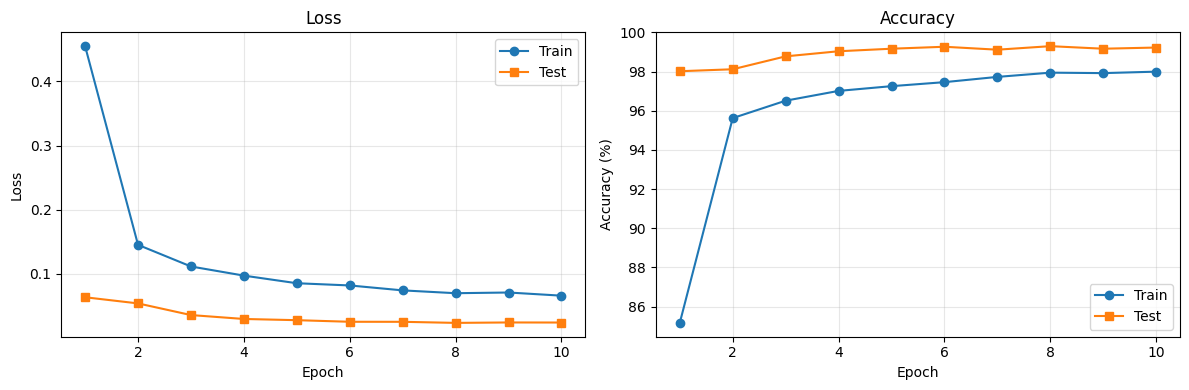

In [24]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 10
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')
     

epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

Epoch 5: train_loss=2.3771  train_acc=12.05%  test_loss=2.3748  test_acc=12.44%
Epoch 10: train_loss=2.3771  train_acc=12.05%  test_loss=2.3748  test_acc=12.44%
-> Cả 2 đều không chênh lệch
Train_acc và test_acc cũng không mở rộng khoảng cách -> Là dấu hiệu của underfitting

In [ ]:
import copy
base_model = MNIST_CNN().to(device)
initial_state = copy.deepcopy(base_model.state_dict())

lrs = [0.001, 0.01, 0.1]
num_epochs = 5

all_loss_histories = {}

for lr in lrs:
    # 🔥 reset model về trạng thái ban đầu
    model = MNIST_CNN().to(device)
    model.load_state_dict(initial_state)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss, total = 0.0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total += labels.size(0)

        train_loss = running_loss / total
        loss_history.append(train_loss)

        print(f"lr={lr} | epoch {epoch+1} | loss={train_loss:.4f}")

    all_loss_histories[lr] = loss_history

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6,4))
for lr in lrs:
    plt.plot(epochs, all_loss_histories[lr], marker='o', label=f'lr={lr}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss comparison for different learning rates')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
print(device)

In [ ]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

In [ ]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model.conv1(img))   # (1, 16, 26, 26)
    p1 = model.pool(h1)                 # (1, 16, 13, 13)
    h2 = torch.relu(model.conv2(p1))    # (1, 32, 11, 11)  <-- conv2 feature map

# ===== Vẽ =====
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# Ảnh gốc
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc')
axes[0, 0].axis('off')

# conv1 (7 kênh)
for i in range(7):
    axes[0, i+1].imshow(h1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}')
    axes[0, i+1].axis('off')

# conv2 (8 kênh như cũ)
for i in range(6):
    axes[1, i].imshow(h2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}')
    axes[1, i].axis('off')

# 👉 thêm 2 feature map mới (ví dụ #6, #7)
axes[1, 6].imshow(h2[0, 6].cpu(), cmap='gray')
axes[1, 6].set_title('conv2 #6')
axes[1, 6].axis('off')

axes[1, 7].imshow(h2[0, 7].cpu(), cmap='gray')
axes[1, 7].set_title('conv2 #7')
axes[1, 7].axis('off')

plt.tight_layout()
plt.show()

Feature map của conv1 chủ yếu phát hiện các đặc trưng mức thấp như cạnh và đường viền, nên dễ quan sát và mang tính cục bộ. Trong khi đó, feature map của conv2 là sự kết hợp của nhiều đặc trưng từ conv1, biểu diễn các cấu trúc phức tạp hơn như hình dạng hoặc các phần của chữ số, do đó mang tính trừu tượng cao hơn và khó diễn giải trực tiếp.

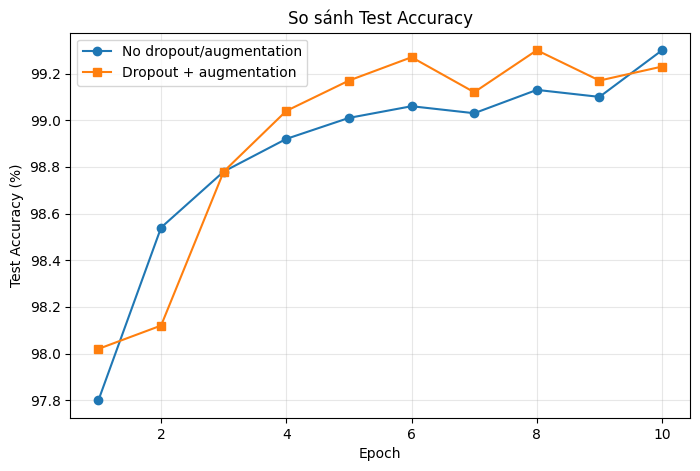

In [26]:
#Biểu đồ so sánh test accuracy giữa baseline (không dropout/augmentation) và mô hình có dropout + augmentation.
epochs = range(1, 11)

baseline_acc = [97.80, 98.54, 98.78, 98.92, 99.01, 99.06, 99.03, 99.13, 99.10, 99.30]
aug_acc =      [98.02, 98.12, 98.78, 99.04, 99.17, 99.27, 99.12, 99.30, 99.17, 99.23]

plt.figure(figsize=(8,5))
plt.plot(epochs, baseline_acc, 'o-', label='No dropout/augmentation')
plt.plot(epochs, aug_acc, 's-', label='Dropout + augmentation')

plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('So sánh Test Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Dropout: tắt ngẫu nhiên neuron khi train → mạng không phụ thuộc vào neuron cụ thể → học tổng quát hơn → giảm overfitting.
Data augmentation: tạo thêm dữ liệu biến thể → dữ liệu đa dạng hơn → model học bản chất thay vì “học thuộc” → giảm overfitting.